# Storm-Level Missing Wind Data Analysis
This notebook analyzes the completeness of the `max_wind_kt` (maximum wind speed) feature on a per-storm basis. Specifically, we want to find out how many storms have less than 15% missing wind data across different time periods.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('../../Datasets/data.csv', low_memory=False)
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year


## Aggregate by Storm
We group the rows by `international_id` to compute the total number of records per storm and how many of those records are missing the wind feature.

In [13]:
# Group by storm (international_id)
storms = df.groupby('international_id').agg(
    start_year=('time', lambda x: x.dt.year.min()),
    total_lines=('max_wind_kt', 'size'),
    missing_wind=('max_wind_kt', lambda x: x.isna().sum())
).reset_index()

# Calculate the percentage of missing wind data for each storm
storms['missing_pct'] = storms['missing_wind'] / storms['total_lines']

storms.head()

,international_id,start_year,total_lines,missing_wind,missing_pct
0,1,2000,53,0,0.0
1,2,2000,31,0,0.0
2,3,2000,40,0,0.0
3,4,2000,37,0,0.0
4,5,2000,28,0,0.0


## Results by Time Period
Now we calculate how many storms are missing < 15% of their wind feature, and their percentage relative to all storms in the period.

In [14]:
periods = [
    ('Overall', 0),
    ('1977-present', 1977),
    ('1980-present', 1980),
    ('1990-present', 1990)
]

for name, start_yr in periods:
    period_storms = storms[storms['start_year'] >= start_yr]
    total_storms = len(period_storms)
    valid_storms = len(period_storms[period_storms['missing_pct'] < 0.15])
    
    pct = (valid_storms / total_storms * 100) if total_storms > 0 else 0
    
    print(f'=== {name} ===')
    print(f'Total storms: {total_storms}')
    print(f'Storms with <15% missing wind data: {valid_storms}')
    print(f'Percentage: {pct:.2f}%\n')

=== Overall ===
Total storms: 1955
Storms with <15% missing wind data: 1248
Percentage: 63.84%

=== 1977-present ===
Total storms: 1248
Storms with <15% missing wind data: 1248
Percentage: 100.00%

=== 1980-present ===
Total storms: 1173
Storms with <15% missing wind data: 1173
Percentage: 100.00%

=== 1990-present ===
Total storms: 903
Storms with <15% missing wind data: 903
Percentage: 100.00%



## Missing Features by Storm Grade
Here we rank the storm grades by their percentage of missing features per record (from most missing to least missing) across the different time periods.
We are specifically analyzing the completeness of the following detailed subset of features:
`max_wind_kt`, `dir_50kt`, `dir_50kt_name`, `rad_50kt_long_nm`, `rad_50kt_short_nm`, `dir_30kt`, `dir_30kt_name`, `rad_30kt_long_nm`, `rad_30kt_short_nm`, `landfall_flag`, `flag_last`, `time_diff_hours`, `revision_date`.

In [15]:
target_features = [
    "max_wind_kt",
    "dir_50kt", "dir_50kt_name", "rad_50kt_long_nm", "rad_50kt_short_nm",
    "dir_30kt", "dir_30kt_name", "rad_30kt_long_nm", "rad_30kt_short_nm",
    "landfall_flag", "flag_last", "time_diff_hours", "revision_date"
]

for name, start_yr in periods:
    period_data = df[df['year'] >= start_yr].copy()
    
    # Calculate the percentage of missing values per row specifically for target_features
    period_data['missing_pct'] = period_data[target_features].isnull().mean(axis=1)
    
    # Group by grade_name and calculate the average missing percentage
    grade_missing = period_data.groupby('grade_name')['missing_pct'].mean().reset_index()
    
    if not grade_missing.empty:
        print(f'=== {name} Ranking ===')
        ranked = grade_missing.sort_values('missing_pct', ascending=False)
        for i, row in ranked.iterrows():
            print(f"{row['grade_name']}: {row['missing_pct']*100:.2f}% missing")
        print("\n")


=== Overall Ranking ===
TC of TS intensity or higher: 76.92% missing
Tropical Depression (TD): 72.31% missing
Extra-tropical Cyclone (L): 72.05% missing
Entering RSMC area: 34.73% missing
Tropical Storm (TS): 7.64% missing
Typhoon (TY): 7.62% missing
Severe Tropical Storm (STS): 7.60% missing


=== 1977-present Ranking ===
Extra-tropical Cyclone (L): 69.23% missing
Tropical Depression (TD): 69.23% missing
Entering RSMC area: 28.91% missing
Tropical Storm (TS): 7.64% missing
Typhoon (TY): 7.62% missing
Severe Tropical Storm (STS): 7.60% missing


=== 1980-present Ranking ===
Extra-tropical Cyclone (L): 69.23% missing
Tropical Depression (TD): 69.23% missing
Entering RSMC area: 28.91% missing
Tropical Storm (TS): 7.64% missing
Typhoon (TY): 7.62% missing
Severe Tropical Storm (STS): 7.60% missing


=== 1990-present Ranking ===
Extra-tropical Cyclone (L): 69.23% missing
Tropical Depression (TD): 69.23% missing
Entering RSMC area: 25.64% missing
Tropical Storm (TS): 7.62% missing
Typhoon (

## Missing 30-knot and 50-knot Wind Radii by Grade
This section ranks storm grades based strictly on how often they are missing the 30-knot and 50-knot wind speed/direction features. This illustrates exactly why weaker/non-tropical systems rank highly for missing data.

In [16]:
wind_radii_features = [
    "dir_50kt", "dir_50kt_name", "rad_50kt_long_nm", "rad_50kt_short_nm",
    "dir_30kt", "dir_30kt_name", "rad_30kt_long_nm", "rad_30kt_short_nm"
]

for name, start_yr in periods:
    period_data = df[df['year'] >= start_yr].copy()
    
    period_data['missing_pct'] = period_data[wind_radii_features].isnull().mean(axis=1)
    grade_missing = period_data.groupby('grade_name')['missing_pct'].mean().reset_index()
    
    if not grade_missing.empty:
        print(f'=== {name} Ranking (Wind Radii Only) ===')
        ranked = grade_missing.sort_values('missing_pct', ascending=False)
        for i, row in ranked.iterrows():
            print(f"{row['grade_name']}: {row['missing_pct']*100:.2f}% missing")
        print("\n")


=== Overall Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missing
TC of TS intensity or higher: 100.00% missing
Entering RSMC area: 42.42% missing
Severe Tropical Storm (STS): 0.00% missing
Tropical Storm (TS): 0.00% missing
Typhoon (TY): 0.00% missing


=== 1977-present Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missing
Entering RSMC area: 34.48% missing
Severe Tropical Storm (STS): 0.00% missing
Tropical Storm (TS): 0.00% missing
Typhoon (TY): 0.00% missing


=== 1980-present Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missing
Entering RSMC area: 34.48% missing
Severe Tropical Storm (STS): 0.00% missing
Tropical Storm (TS): 0.00% missing
Typhoon (TY): 0.00% missing


=== 1990-present Ranking (Wind Radii Only) ===
Extra-tropical Cyclone (L): 100.00% missing
Tropical Depression (TD): 100.00% missin

## Storm Grade Progression
Let's pick a random storm from the dataset and observe how its `grade_name` evolves chronologically over its lifespan.

In [17]:
# Pick a random storm (using a set random seed for reproducibility in output, or omit for truly random)
random_storm_id = np.random.choice(df['international_id'].dropna().unique())
storm_data = df[df['international_id'] == random_storm_id].sort_values('time')

storm_name = storm_data['name'].iloc[0]
print(f"Random Storm ID: {random_storm_id} (Name: {storm_name})")
print("Grade progression over time (showing points of transition):")

grade_progression = storm_data[['time', 'grade_name']].dropna()
previous_grade = None

for _, row in grade_progression.iterrows():
    current_grade = row['grade_name']
    if current_grade != previous_grade:
        print(f"  {row['time']} -> {current_grade}")
        previous_grade = current_grade


Random Storm ID: 7126 (Name: WENDY)
Grade progression over time (showing points of transition):
  1971-09-04 00:00:00 -> Tropical Depression (TD)
  1971-09-05 00:00:00 -> TC of TS intensity or higher
  1971-09-13 18:00:00 -> Extra-tropical Cyclone (L)


## Extra-tropical Cyclone Analysis
Let's plot the geographical positions of all storms when they are in the `Extra-tropical Cyclone (L)` state, mapped onto the entire region of the Western North Pacific.

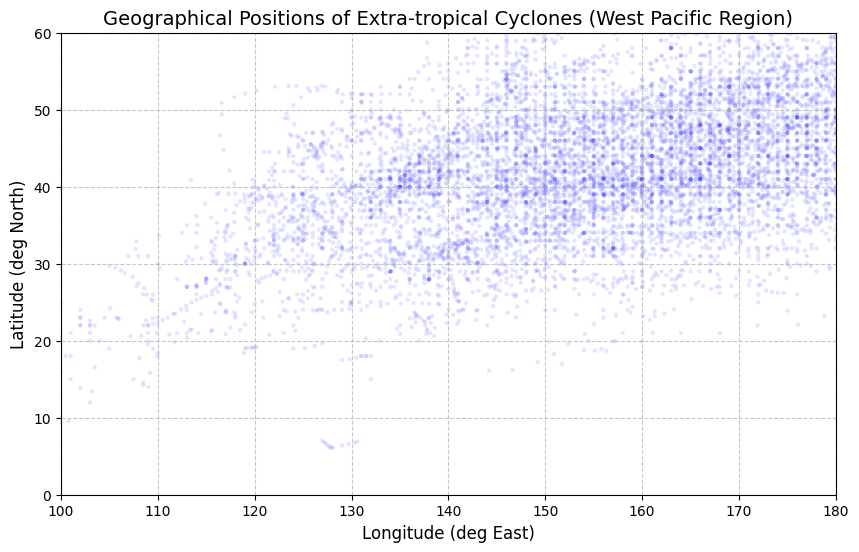

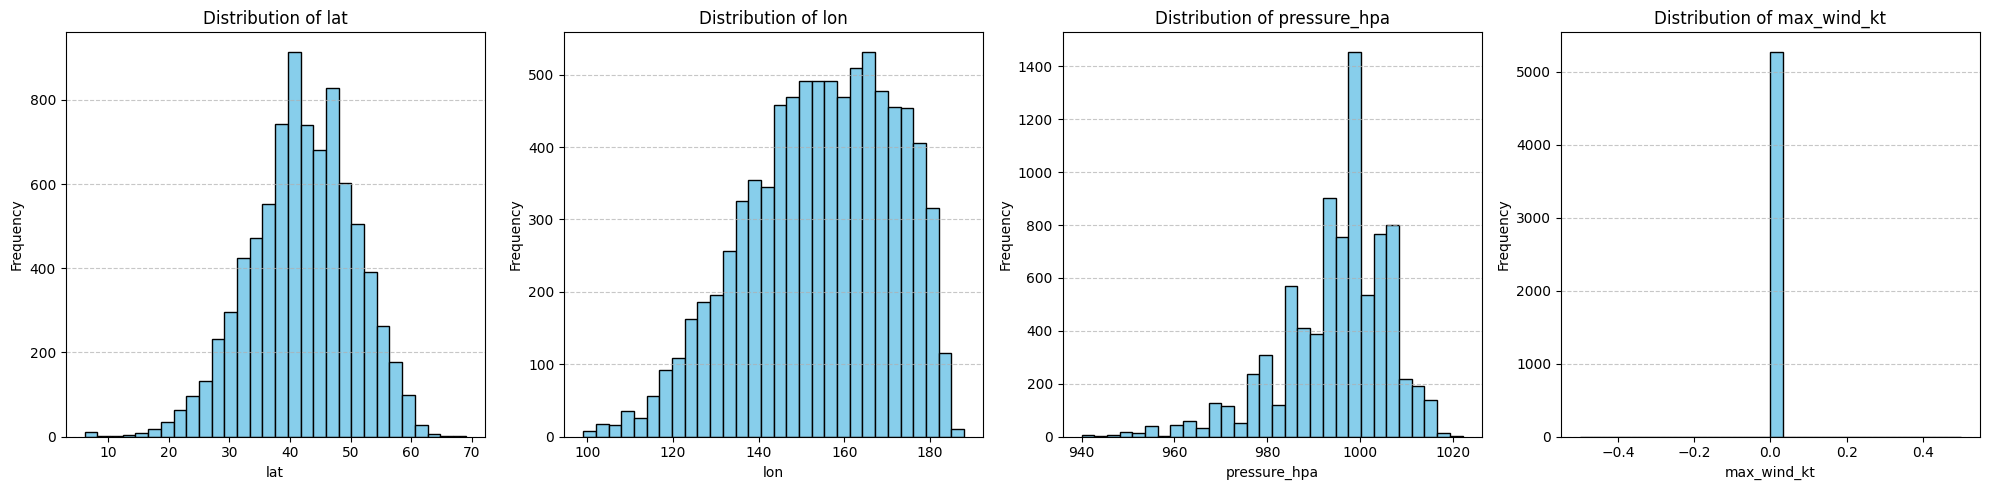

In [18]:
# Filter data for Extra-tropical Cyclones
extratropical = df[df['grade_name'] == 'Extra-tropical Cyclone (L)'].copy()

# 1. Plot geographical positions in the context of the Western North Pacific
plt.figure(figsize=(10, 6))
plt.scatter(extratropical['lon'], extratropical['lat'], alpha=0.1, s=10, c='blue', edgecolors='none')

# Set the bounding box for the RSMC Tokyo-Typhoon Center area of responsibility (Western Pacific)
# Longitude: 100 E to 180 E, Latitude: Equator (0) to 60 N
plt.xlim(100, 180)
plt.ylim(0, 60)

plt.title('Geographical Positions of Extra-tropical Cyclones (West Pacific Region)', fontsize=14)
plt.xlabel('Longitude (deg East)', fontsize=12)
plt.ylabel('Latitude (deg North)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Plot feature distributions
features_to_plot = ['lat', 'lon', 'pressure_hpa']
if not extratropical['max_wind_kt'].isna().all():
    features_to_plot.append('max_wind_kt')

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(5 * len(features_to_plot), 5))
for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    extratropical[feat].dropna().plot.hist(ax=ax, bins=30, edgecolor='black', color='skyblue')
    ax.set_title(f'Distribution of {feat}', fontsize=12)
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Dataset Features
Finding out what the features inside the dataset are.

In [19]:
# Find out what the features inside the dataset are
print("Features in the dataset:")
print(df.columns.tolist())

Features in the dataset:
['international_id', 'tc_number', 'name', 'time', 'grade', 'grade_name', 'lat', 'lon', 'pressure_hpa', 'max_wind_kt', 'dir_50kt', 'dir_50kt_name', 'rad_50kt_long_nm', 'rad_50kt_short_nm', 'dir_30kt', 'dir_30kt_name', 'rad_30kt_long_nm', 'rad_30kt_short_nm', 'landfall_flag', 'flag_last', 'time_diff_hours', 'revision_date', 'year']


## Wind Feature Distributions
Plotting the distribution of all wind related features, except for those that represent direction.

Wind related features to plot: ['max_wind_kt', 'rad_50kt_long_nm', 'rad_50kt_short_nm', 'rad_30kt_long_nm', 'rad_30kt_short_nm']


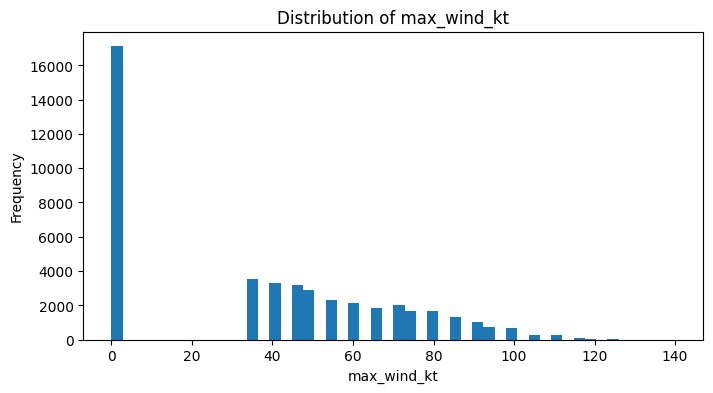

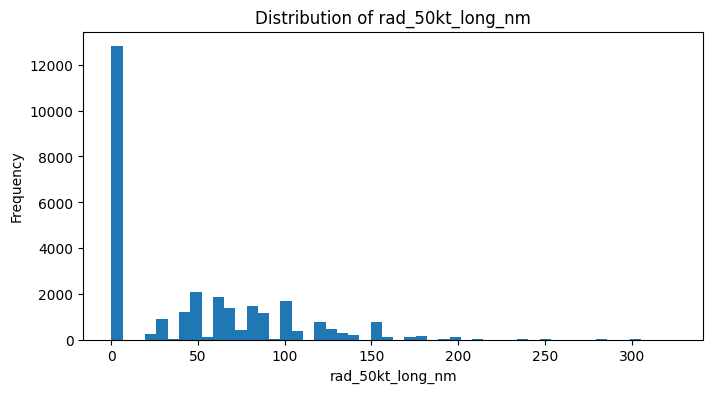

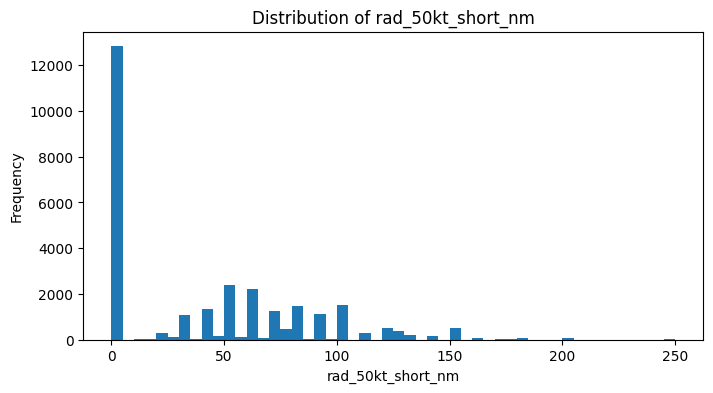

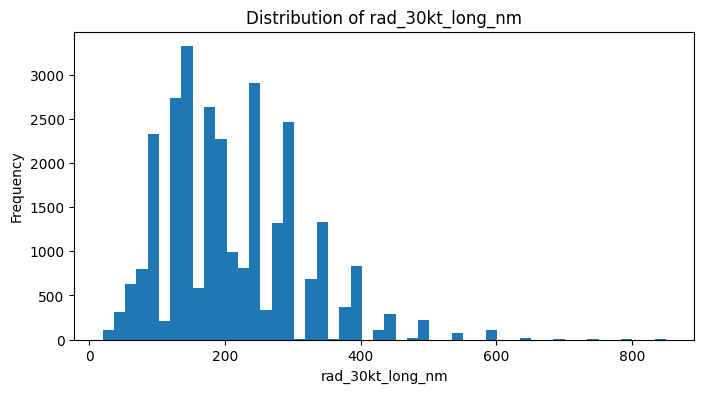

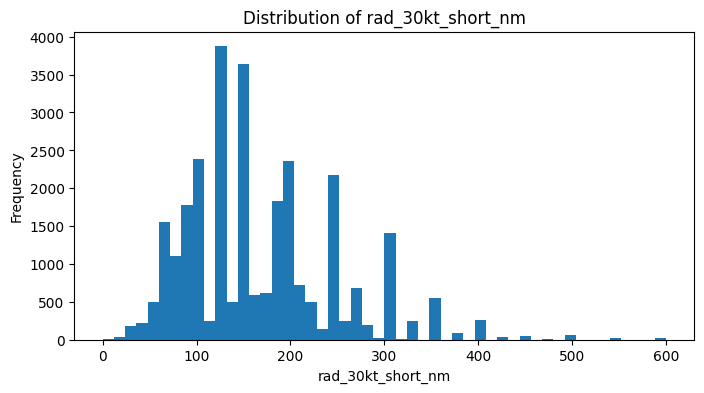

In [20]:
# Plot the distribution of all wind related features, except for those that represent direction
wind_features = [col for col in df.columns if ('wind' in col.lower() or 'kt' in col.lower()) and 'dir' not in col.lower()]
print("Wind related features to plot:", wind_features)

for feature in wind_features:
    plt.figure(figsize=(8, 4))
    df[feature].plot(kind='hist', bins=50, title=f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

## Time Difference Between Records (`time_diff_hours`) - 1980 to Present
Checking the unique values, frequencies, and distributions of `time_diff_hours` for all storms starting from **1980 to present** across both record level and per-storm header level.

In [21]:
# 1. Filter storms starting from 1980 to present
storm_start_years = df.groupby('international_id')['time'].min().dt.year
storms_1980_ids = storm_start_years[storm_start_years >= 1980].index
df_1980 = df[df['international_id'].isin(storms_1980_ids)].copy()

print(f"Total storms starting from 1980 to present: {len(storms_1980_ids)}")
print(f"Total records for storms from 1980 to present: {len(df_1980)}")

# 2. Check unique values and distribution of time_diff_hours
print("\nUnique values in 'time_diff_hours' (1980-present):")
unique_time_diff = df_1980['time_diff_hours'].unique()
print(unique_time_diff)

print("\nValue counts and percentage distribution of 'time_diff_hours' across records (1980-present):")
counts = df_1980['time_diff_hours'].value_counts(dropna=False)
pcts = df_1980['time_diff_hours'].value_counts(dropna=False, normalize=True) * 100
time_diff_df = pd.DataFrame({
    'Unique Value (Hours)': counts.index,
    'Record Count': counts.values,
    'Percentage (%)': pcts.round(2).values
})
print(time_diff_df.to_string(index=False))

print("\nDistribution of 'time_diff_hours' per storm header (1980-present):")
storm_td_counts = df_1980.groupby('international_id')['time_diff_hours'].first().value_counts(dropna=False)
storm_td_pcts = df_1980.groupby('international_id')['time_diff_hours'].first().value_counts(dropna=False, normalize=True) * 100
storm_td_df = pd.DataFrame({
    'Header Value (Hours)': storm_td_counts.index,
    'Storm Count': storm_td_counts.values,
    'Percentage (%)': storm_td_pcts.round(2).values
})
print(storm_td_df.to_string(index=False))


Total storms starting from 1980 to present: 1173
Total records for storms from 1980 to present: 43156

Unique values in 'time_diff_hours' (1980-present):
[0 6 3]

Value counts and percentage distribution of 'time_diff_hours' across records (1980-present):
 Unique Value (Hours)  Record Count  Percentage (%)
                    6         35398           82.02
                    0          7244           16.79
                    3           514            1.19

Distribution of 'time_diff_hours' per storm header (1980-present):
 Header Value (Hours)  Storm Count  Percentage (%)
                    6          990           84.40
                    0          168           14.32
                    3           15            1.28


## Storm Trajectory Splitting & Time Elapsed From First State - 1980 to Present
Splitting the dataset into an array of individual storm DataFrames for storms starting from **1980 to present**, and analyzing the difference in hours between the first state and each subsequent state for every storm.

In [22]:
# 1. Split dataset into an array of different storms (1980 to present) based on international_id
# Ensure records for each storm are sorted chronologically by time
storms_array_1980 = [
    group.sort_values('time').reset_index(drop=True)
    for _, group in df_1980.groupby('international_id')
]

print(f"Total number of storms in array (1980-present): {len(storms_array_1980)}")

# 2. Calculate the difference in hours between the first state of each storm and each of its states
for storm_df in storms_array_1980:
    first_state_time = storm_df['time'].iloc[0]
    # Elapsed hours from storm genesis/first recorded state
    storm_df['hours_from_first_state'] = (storm_df['time'] - first_state_time).dt.total_seconds() / 3600.0
    # Step difference between consecutive states in hours
    storm_df['step_diff_hours'] = (storm_df['time'].diff().dt.total_seconds() / 3600.0).fillna(0)

# 3. Aggregate elapsed hours across all states of all storms (1980-present)
all_hours_from_start_1980 = pd.concat([s['hours_from_first_state'] for s in storms_array_1980])
print("\nDescriptive statistics of hours from first state (across all states in 1980-present storms):")
print(all_hours_from_start_1980.describe())

# 4. Total duration (lifespan) per storm in hours (time from first state to last state)
storm_durations_1980 = pd.Series([s['hours_from_first_state'].iloc[-1] for s in storms_array_1980], name="storm_duration_hours")
print("\nDescriptive statistics of storm total lifespans (max hours from first state per storm, 1980-present):")
print(storm_durations_1980.describe())

# 5. Distribution of consecutive time step intervals (hours between successive reports)
all_step_diffs_1980 = pd.concat([s['step_diff_hours'] for s in storms_array_1980])
print("\nMost common time intervals between consecutive states (hours, 1980-present):")
print(all_step_diffs_1980.value_counts().head(5).to_string())

# 6. Display sample storm trajectory showing time progression from first state
sample_storm = storms_array_1980[0]
storm_id = sample_storm['international_id'].iloc[0]
storm_name = sample_storm['name'].iloc[0] if 'name' in sample_storm.columns else 'Unknown'
print(f"\nSample Storm ID {storm_id} ({storm_name}) - First 10 states:")
print(sample_storm[['time', 'grade_name', 'lat', 'lon', 'max_wind_kt', 'hours_from_first_state', 'step_diff_hours', 'time_diff_hours']].head(10).to_string(index=False))


Total number of storms in array (1980-present): 1173

Descriptive statistics of hours from first state (across all states in 1980-present storms):
count    43156.000000
mean       121.035267
std         86.717426
min          0.000000
25%         54.000000
50%        108.000000
75%        174.000000
max        522.000000
Name: hours_from_first_state, dtype: float64

Descriptive statistics of storm total lifespans (max hours from first state per storm, 1980-present):
count    1173.000000
mean      200.442455
std        86.034903
min        12.000000
25%       138.000000
50%       192.000000
75%       252.000000
max       522.000000
Name: storm_duration_hours, dtype: float64

Most common time intervals between consecutive states (hours, 1980-present):
step_diff_hours
6.0    36552
3.0     5093
0.0     1173
1.0      173
2.0      154

Sample Storm ID 1 (DAMREY) - First 10 states:
               time               grade_name  lat   lon  max_wind_kt  hours_from_first_state  step_diff_hours  t

## Grade and Grade Name Distribution by `time_diff_hours` (0, 3, and 6)
Analyzing the storm intensity `grade` (numerical code) and `grade_name` distribution individually for each distinct `time_diff_hours` value (**0**, **3**, and **6** hours), comparing both counts and proportions across the 1980–present period and overall.

In [23]:
# Grade and grade_name distribution split by time_diff_hours (0, 3, and 6)

# 1. Analysis for storms starting from 1980 to present
print("=================================================================")
print("=== 1980 TO PRESENT: Grade Distribution by time_diff_hours ===")
print("=================================================================")

for td_val in [0, 3, 6]:
    sub = df_1980[df_1980['time_diff_hours'] == td_val]
    print(f"\n--- time_diff_hours = {td_val} (Total: {len(sub):,} records) ---")
    dist = sub.groupby(['grade', 'grade_name']).size().reset_index(name='Record Count')
    dist['Percentage (%)'] = (dist['Record Count'] / len(sub) * 100).round(2)
    dist = dist.sort_values('Record Count', ascending=False)
    print(dist.to_string(index=False))

print("\n--- 1980-Present Comparison: Cross-tabulation of Counts ---")
ct_counts_1980 = pd.crosstab(df_1980['grade_name'], df_1980['time_diff_hours'], margins=True)
print(ct_counts_1980)

print("\n--- 1980-Present Comparison: Column Percentages (%) ---")
ct_pct_1980 = (pd.crosstab(df_1980['grade_name'], df_1980['time_diff_hours'], normalize='columns') * 100).round(2)
print(ct_pct_1980)

# 2. Analysis for Overall Dataset
print("\n\n===============================================================")
print("=== OVERALL DATASET: Grade Distribution by time_diff_hours ===")
print("===============================================================")

for td_val in [0, 3, 6]:
    sub = df[df['time_diff_hours'] == td_val]
    print(f"\n--- time_diff_hours = {td_val} (Total: {len(sub):,} records) ---")
    dist = sub.groupby(['grade', 'grade_name']).size().reset_index(name='Record Count')
    dist['Percentage (%)'] = (dist['Record Count'] / len(sub) * 100).round(2)
    dist = dist.sort_values('Record Count', ascending=False)
    print(dist.to_string(index=False))

print("\n--- Overall Comparison: Cross-tabulation of Counts ---")
ct_counts_all = pd.crosstab(df['grade_name'], df['time_diff_hours'], margins=True)
print(ct_counts_all)

print("\n--- Overall Comparison: Column Percentages (%) ---")
ct_pct_all = (pd.crosstab(df['grade_name'], df['time_diff_hours'], normalize='columns') * 100).round(2)
print(ct_pct_all)


=== 1980 TO PRESENT: Grade Distribution by time_diff_hours ===

--- time_diff_hours = 0 (Total: 7,244 records) ---
 grade                  grade_name  Record Count  Percentage (%)
     5                Typhoon (TY)          2217           30.60
     6  Extra-tropical Cyclone (L)          1552           21.42
     3         Tropical Storm (TS)          1219           16.83
     2    Tropical Depression (TD)          1179           16.28
     4 Severe Tropical Storm (STS)          1069           14.76
     7          Entering RSMC area             8            0.11

--- time_diff_hours = 3 (Total: 514 records) ---
 grade                  grade_name  Record Count  Percentage (%)
     2    Tropical Depression (TD)           141           27.43
     5                Typhoon (TY)           136           26.46
     3         Tropical Storm (TS)           106           20.62
     4 Severe Tropical Storm (STS)            83           16.15
     6  Extra-tropical Cyclone (L)            48       

## Modulo 6 Analysis of Elapsed Hours from First State
Checking whether the time difference between each state and the first timestamp ($t_k - t_0$) remains a strict multiple of 6 hours (`elapsed % 6 == 0`), or if other values/remainders exist when `time_diff_hours` is `0`, `3`, or `6`.

In [24]:
# Analysis: Is (time - t0) always a multiple of 6 hours when time_diff_hours is 0, 3, or 6?

def analyze_elapsed_mod6(data_subset, label):
    print(f"========================================================")
    print(f"=== {label} ===")
    print(f"========================================================")
    
    records = []
    for s_id, storm in data_subset.groupby('international_id'):
        storm = storm.sort_values('time').reset_index(drop=True)
        t0 = storm['time'].iloc[0]
        td_val = storm['time_diff_hours'].iloc[0]
        
        elapsed = (storm['time'] - t0).dt.total_seconds() / 3600.0
        step = (storm['time'].diff().dt.total_seconds() / 3600.0).fillna(0)
        
        for idx in range(len(storm)):
            records.append({
                'international_id': s_id,
                'time_diff_hours': td_val,
                'elapsed_hours': elapsed.iloc[idx],
                'step_hours': step.iloc[idx],
                'remainder_6': elapsed.iloc[idx] % 6,
                'is_multiple_of_6': (elapsed.iloc[idx] % 6) == 0
            })
            
    res_df = pd.DataFrame(records)
    
    for td in [0, 3, 6]:
        sub = res_df[res_df['time_diff_hours'] == td]
        if len(sub) == 0:
            continue
        print(f"\n--- time_diff_hours = {td} (Total: {len(sub):,} records) ---")
        
        # Remainder distribution
        rem_counts = sub['remainder_6'].value_counts().sort_index()
        rem_pcts = (sub['remainder_6'].value_counts(normalize=True).sort_index() * 100).round(2)
        rem_table = pd.DataFrame({
            '(t - t0) % 6 Remainder': rem_counts.index,
            'Record Count': rem_counts.values,
            'Percentage (%)': rem_pcts.values
        })
        print(rem_table.to_string(index=False))
        
        # Step deltas between consecutive reports
        print("\nTop consecutive step intervals (dt hours):")
        print(sub['step_hours'].value_counts().head(5).to_string())

# Run for 1980-present and overall
analyze_elapsed_mod6(df_1980, '1980 to Present')
analyze_elapsed_mod6(df, 'Overall Dataset')


=== 1980 to Present ===

--- time_diff_hours = 0 (Total: 7,244 records) ---
 (t - t0) % 6 Remainder  Record Count  Percentage (%)
                    0.0          6634           91.58
                    1.0             9            0.12
                    2.0             9            0.12
                    3.0           564            7.79
                    4.0            11            0.15
                    5.0            17            0.23

Top consecutive step intervals (dt hours):
step_hours
6.0    5900
3.0    1086
0.0     168
1.0      47
2.0      41

--- time_diff_hours = 3 (Total: 514 records) ---
 (t - t0) % 6 Remainder  Record Count  Percentage (%)
                    0.0           513           99.81
                    3.0             1            0.19

Top consecutive step intervals (dt hours):
step_hours
6.0    497
0.0     15
3.0      2

--- time_diff_hours = 6 (Total: 35,398 records) ---
 (t - t0) % 6 Remainder  Record Count  Percentage (%)
                    0.0 

## Real Time Difference Between Consecutive States ($\Delta t = t_k - t_{k-1}$)
Splitting the dataset into an array of storms and evaluating the **true chronological time delta** in hours between each state and its immediate predecessor when `time_diff_hours` is `0`, `3`, and `6`.

In [25]:
# Real time difference between consecutive states (tk - tk-1) per storm array

def analyze_real_step_deltas(data_subset, label):
    print("======================================================================")
    print(f"=== {label} ===")
    print("======================================================================")
    
    # 1. Split dataset into an array of individual storm DataFrames
    storms_array = [
        group.sort_values('time').reset_index(drop=True)
        for _, group in data_subset.groupby('international_id')
    ]
    print(f"Total storms in array: {len(storms_array)}")
    
    # 2. Compute consecutive state time differences within each storm
    transitions = []
    for storm in storms_array:
        td_header = storm['time_diff_hours'].iloc[0]
        s_id = storm['international_id'].iloc[0]
        
        for i in range(1, len(storm)):
            dt = (storm['time'].iloc[i] - storm['time'].iloc[i-1]).total_seconds() / 3600.0
            transitions.append({
                'international_id': s_id,
                'time_diff_hours': td_header,
                'real_dt_hours': dt
            })
            
    trans_df = pd.DataFrame(transitions)
    print(f"Total consecutive transitions evaluated: {len(trans_df):,}\n")
    
    for td in [0, 3, 6]:
        sub = trans_df[trans_df['time_diff_hours'] == td]
        print(f"--- time_diff_hours = {td} (Total transitions: {len(sub):,}) ---")
        
        counts = sub['real_dt_hours'].value_counts().sort_index()
        pcts = (sub['real_dt_hours'].value_counts(normalize=True).sort_index() * 100).round(2)
        
        table = pd.DataFrame({
            'Real Step Delta (Hours)': counts.index,
            'Transition Count': counts.values,
            'Percentage (%)': pcts.values
        })
        print(table.to_string(index=False))
        print()
        
    # Summary comparison cross-tabulation
    print("--- Summary Comparison of Real Time Step Frequencies --- ")
    ct = pd.crosstab(trans_df['real_dt_hours'], trans_df['time_diff_hours'], margins=True)
    print(ct)
    print("\n--- Percentage Breakdown by Column (%) ---")
    print((pd.crosstab(trans_df['real_dt_hours'], trans_df['time_diff_hours'], normalize='columns') * 100).round(2))
    print("\n")

# Run for 1980-present and overall
analyze_real_step_deltas(df_1980, '1980 to Present')
analyze_real_step_deltas(df, 'Overall Dataset')


=== 1980 to Present ===
Total storms in array: 1173
Total consecutive transitions evaluated: 41,983

--- time_diff_hours = 0 (Total transitions: 7,076) ---
 Real Step Delta (Hours)  Transition Count  Percentage (%)
                     1.0                47            0.66
                     2.0                41            0.58
                     3.0              1086           15.35
                     4.0                 1            0.01
                     5.0                 1            0.01
                     6.0              5900           83.38

--- time_diff_hours = 3 (Total transitions: 499) ---
 Real Step Delta (Hours)  Transition Count  Percentage (%)
                     3.0                 2             0.4
                     6.0               497            99.6

--- time_diff_hours = 6 (Total transitions: 34,408) ---
 Real Step Delta (Hours)  Transition Count  Percentage (%)
                     1.0               126            0.37
                     2.0 